# Comparing parallel universes - ecoHeat
When a user has ecoHeat OFF how much could they be saving?
e.g. This is what ecoHeat ON could save you (in a week? day? year?)

In [1]:
# Imports
import ast
import pandas as pd
import requests
from datetime import datetime, timezone, timedelta

from pathlib import Path
from scipy.integrate import trapezoid

from model_helper_functions import get, plot_temp_power

In [2]:
# Set up API call
url = "https://bristol.passivuk.com/optimisation"
with open("API_key.txt", "r") as file:
    API_key = file.read()

#### Research question:
If the user had had ecoHeat enabled - could they have saved money?

## Read in and store data
Must filter data to houses with viable contents for problem we are asking

Data must have: 
- input power
- room temperature
- external temperature
- tariff
- ecoheat indicator (0/1)

Also must:
- Sometimes have ecoHeat disabled (indicator = 0)

In [3]:
# load event files
event_path = Path("data/PSTData5_reformat_v3")
event_files = event_path.glob("*.csv")

houses_events = {}
for file in event_files:
    house_id = file.stem.split("_")[0]
    houses_events[house_id] = pd.read_csv(file)
    houses_events[house_id]["Timestamp"] = pd.to_datetime(houses_events[house_id]["Timestamp"])

In [4]:
# Read in, sort and store data to use for problem
temp_path = Path("data/PSTData5")
temp_files = temp_path.glob("*.csv")

houses_temps = {}
houses_without_power = []
houses_without_setpoints = []
houses_without_room_temp = []
houses_without_ext_temp = []
houses_without_tariff = []
houses_without_ecoheat_indicator = []
good_houses_ecoheat_always = []
for file in temp_files:
    if "Events" not in str(file):
        house_id = file.stem.split("_")[0]
        data = pd.read_csv(file)
        temp = {}
        temp["Datetimes"] = pd.to_datetime(data["Time (UTC)"])
        temp["Setpoint Z1"] = data["Setpoint temperature (Zone 1) (°C)"]
        temp["Room Temp Z1"] = data["Room temperature (Zone 1) (°C)"]
        try:
            temp["Setpoint Z2"] = data["Setpoint temperature (Zone 2) (°C)"]
            temp["Room Temp Z2"] = data["Room temperature (Zone 2) (°C)"]
        except KeyError:
            print("Data doesn't have zone 2")
        temp["External Temp"] = data["External temperature (°C)"]
        temp["Input Power"] = data["Power consumption (kW)"]
        temp["Elec Cost (p/kWh)"] = data["Tariff rate (p/kWh)"]
        temp["Ecoheat (0/1)"] = data["Ecoheat (0/1)"]

        # Remove NaNs
        house_df = pd.DataFrame(temp).dropna(axis=1, how="all")  # Drop any columns where all values are NaN
        house_df = house_df.dropna(axis=0, how="any")  # Drop any rows where one or more values are NaN
        
        # Store data
        if "Input Power" not in house_df.columns:
            houses_without_power.append(house_id)
        elif "Setpoint Z1" not in house_df.columns:
            houses_without_setpoints.append(house_id)
        elif "Room Temp Z1" not in house_df.columns:
            houses_without_room_temp.append(house_id)
        elif "External Temp" not in house_df.columns:
            houses_without_ext_temp.append(house_id)
        elif "Elec Cost (p/kWh)" not in house_df.columns:
            houses_without_tariff.append(house_id)
        elif "Ecoheat (0/1)" not in house_df.columns:
            houses_without_ecoheat_indicator.append(house_id)
        elif sum(house_df['Ecoheat (0/1)'] == 0) == 0:
            good_houses_ecoheat_always.append(house_id)
        else:
            houses_temps[house_id] = house_df

print("No power: ", houses_without_power)
print("No setpoints: ", houses_without_setpoints)
print("No room temp: ", houses_without_room_temp)
print("No ext temp: ", houses_without_ext_temp)
print("No tariff: ", houses_without_tariff)
print("No Ecoheat: ", houses_without_ecoheat_indicator)
print("Viable data - ecoHeat never disabled: ", good_houses_ecoheat_always)
print("Data to use: ", list(houses_temps.keys()))

No power:  ['30385', '30594', '29648', '30159', '28828', '29368', '29842', '30531', '29628', '29953', '30568', '29586', '29479', '30436', '30250', '30016', '30383', '30154', '29849', '30118', '29267', '29867', '30456', '29576', '30160', '29296', '30309', '30151', '29962', '30680', '30581', '29612', '29422', '29280', '28246', '30162', '29999', '30447', '29724', '30014', '29722', '29596', '30359', '29627', '29595', '29431', '30097', '30421', '29687', '30069', '30578', '30381', '29456', '29998', '28190', '29980', '30409', '30587', '29257', '29711', '30375', '30258', '29502', '30222', '30628', '29798', '29937', '29398']
No setpoints:  []
No room temp:  []
No ext temp:  ['30306', '30365']
No tariff:  []
No Ecoheat:  []
Viable data - ecoHeat never disabled:  ['29700', '28352', '30550', '30046', '29947', '29846', '29466', '29824', '28788', '28679', '29985', '29494', '29310', '29997', '30552', '29390', '29685', '30656', '29692', '30715', '30668', '29316', '30641', '30243']
Data to use:  ['3005

In [5]:
event_df = houses_events["30055"]
temp_df = houses_temps["30055"]

In [6]:
event_df

,Timestamp,Type,Payload,Override
0,2025-12-23 12:10:10,Presets,"{'user': {'frost': 8, 'away': 8, 'schedule_mod...",NaN
1,2025-12-23 12:10:10,Presets,"{'user': {'frost': 8, 'away': 8, 'schedule_mod...",NaN
2,2025-12-23 12:10:10,Schedule,"{'uri': '/v/1/schedule/away', 'type': 'away', ...",NaN
3,2025-12-23 12:10:12,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'basic'...",NaN
4,2025-12-23 12:10:13,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'basic'...",NaN
...,...,...,...,...
257,2026-03-01 16:58:11,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'basic'...","{'hours': ['2026-03-01T16:58:10Z'], 'C': [21.5]}"
258,2026-03-01 16:58:14,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'basic'...","{'hours': ['2026-03-01T16:58:14Z'], 'C': [22.5]}"
259,2026-03-04 09:29:18,Schedule,"{'type': 'heating', 'zone': 1, 'mode': 'basic'...","{'hours': ['2026-03-04T09:29:18Z'], 'C': [18.0]}"
260,2026-03-04 19:21:23,Schedule,"{'type': 'heating', 'zone': 2, 'mode': 'basic'...","{'hours': ['2026-03-04T19:21:22Z'], 'C': [22.0]}"


In [7]:
temp_df

,Datetimes,Setpoint Z1,Room Temp Z1,Setpoint Z2,Room Temp Z2,External Temp,Input Power,Elec Cost (p/kWh),Ecoheat (0/1)
153,2025-12-24 01:00:00,17.0,20.7,17.0,20.6,5.0,0.01,25.64,0.0
154,2025-12-24 01:05:00,17.0,20.5,17.0,20.4,5.0,0.01,25.64,0.0
155,2025-12-24 01:10:00,17.0,20.5,17.0,20.4,5.0,0.01,25.64,0.0
156,2025-12-24 01:15:00,17.0,20.5,17.0,20.4,5.0,0.01,25.64,0.0
157,2025-12-24 01:20:00,17.0,20.5,17.0,20.4,5.0,0.01,25.64,0.0
...,...,...,...,...,...,...,...,...,...
21737,2026-03-08 23:40:00,21.0,21.7,21.0,22.7,10.0,0.00,23.51,0.0
21738,2026-03-08 23:45:00,21.0,21.7,21.0,22.7,10.0,0.00,23.51,0.0
21739,2026-03-08 23:50:00,21.0,21.5,21.0,22.7,10.0,0.00,23.51,0.0
21740,2026-03-08 23:55:00,21.0,21.5,21.0,22.4,10.0,0.00,23.51,0.0


### Understand house

In [8]:
print("Number of datapoints: ", len(temp_df))
print("Number of datapoints with Ecoheat disabled:", sum(temp_df['Ecoheat (0/1)'] == 0))

Number of datapoints:  21546
Number of datapoints with Ecoheat disabled: 21546


No output power


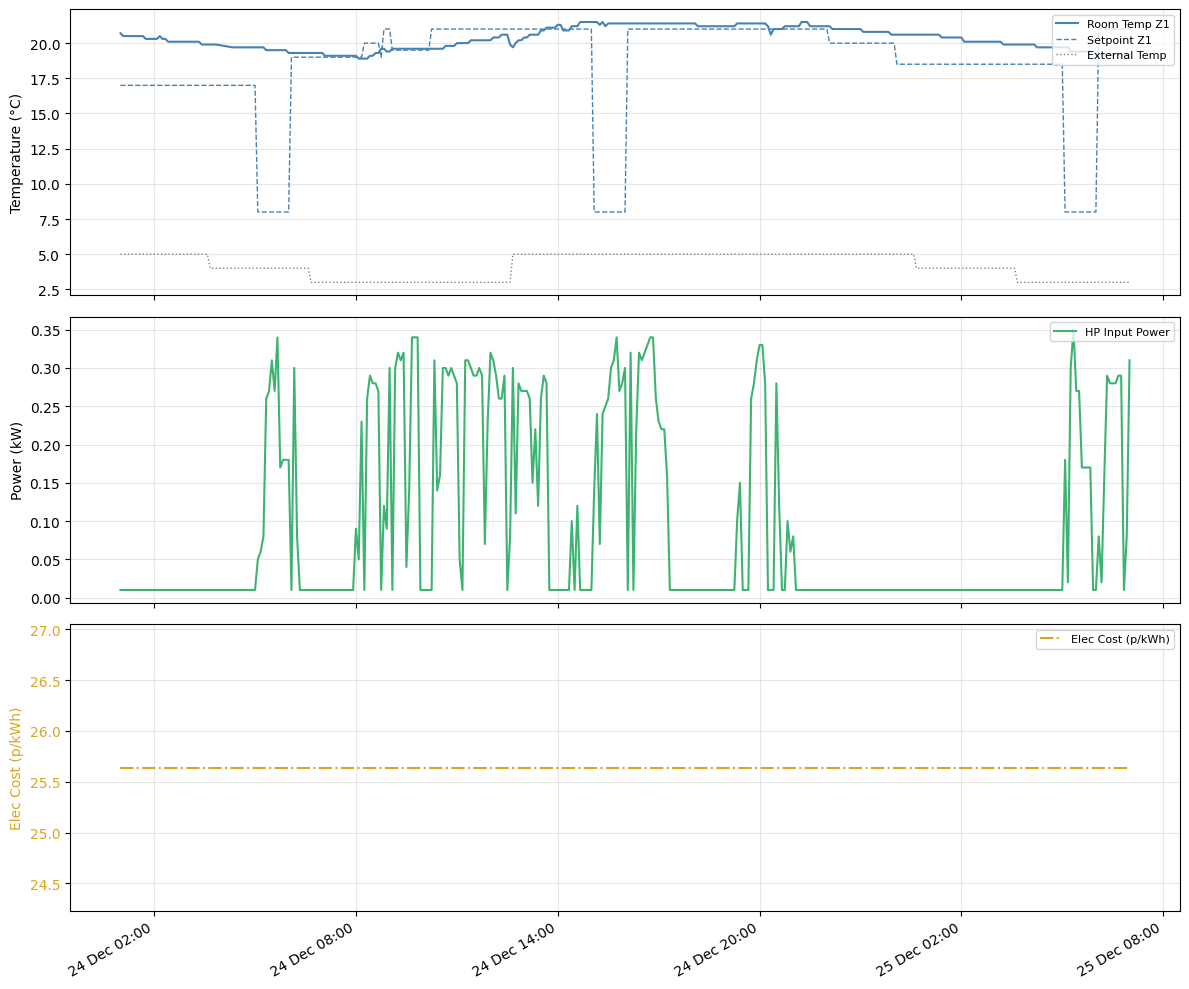

Data covers 30.0 hours (356 timesteps)


In [9]:
i = 153
plot_temp_power(temp_df.loc[i:i+(30*60/5)], 1)

### Extract schedule

In [ ]:
# Filter to schedules
mask = event_df["Type"] == "Schedule"
schedules = event_df.loc[mask, ["Timestamp", "Payload"]]

# Preprocess data: remove non-heating schedules and format payloads
schedules_dict = {}
for i, row in schedules.iterrows():
    time = row.get("Timestamp")
    data = row.get("Payload")
    override = row.get("Override")
    if isinstance(data, str): # if payload is string, convert to dict
        data = ast.literal_eval(data)
    if data.get("type") == "heating": # only use heating schedules
        schedules_dict[time] = data["schedule"]
print(schedules_dict)

# Time at start of data range
time = temp_df.iloc[i]["Datetimes"]
print(time)
days_of_week = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
weekday = days_of_week[time.weekday()]
print(weekday)

# Extract time nearest (before) or equal to time from dataset to find applicable schedule
nearest_time = min((t for t in schedules_dict.keys() if t < time), key=lambda t: time - t)
print(nearest_time)
applicable_schedule = schedules_dict[nearest_time][weekday]
print(applicable_schedule)
# NOTE: applicabel schedule not quite right for 30 hour generations will be that day and the next, but model API too simple and can't have distinct days

{Timestamp('2025-12-23 12:10:12'): {'mon': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'tue': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'wed': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'thu': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'fri': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'sat': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'sun': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}}, Timestamp('2025-12-23 12:10:13'): {'mon': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'tue': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'wed': {'hours': [0, 5, 6, 9, 15, 16, 22], 'C': [17, 'frost', 19, 17, 'frost', 20, 17]}, 'thu': {'hours': [0, 5, 6, 9, 15, 16, 

In [32]:
# Two schedules to compare
schedule_1_input = {
"num_zones": 1,
"zone_1_heating_daily_schedule": applicable_schedule,
"start_datetime": time.strftime("%Y-%m-%dT%H:%M:%SZ"),
# "zone_1_temperature": 19 <- default
}

# schedule_2_input = {
# "num_zones": 1,
# "zone_1_heating_daily_schedule": {"hours": [8, 10, 14, 16], "C": [20, 'frost', 20, 'frost']},
# "start_datetime": "2024-01-01T07:00:00Z",
# # "zone_1_temperature": 19 <- default
# }

In [33]:
return_1 = requests.post(url, headers={"X-API-Key": API_key}, json=schedule_1_input).json()

### Plot results

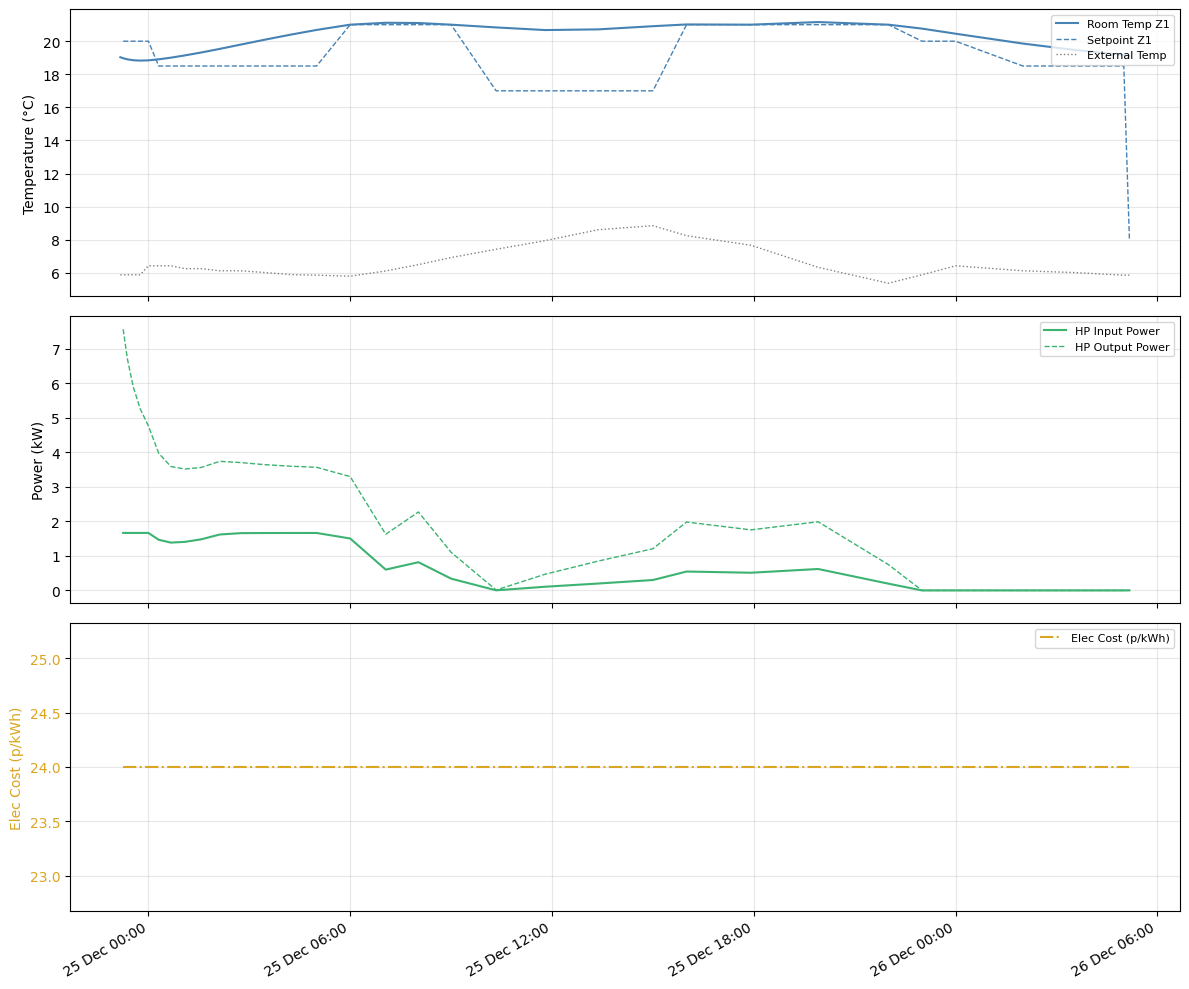

Data covers 30.0 hours (33 timesteps)


In [35]:
if return_1['success']:
    dts = [datetime.fromisoformat(t.replace("Z", "+00:00")) for t in return_1["real_dt"]]
    n = len(dts)
    S = return_1["State"]
    output_data = pd.DataFrame({
        "Datetimes": dts,
        "Setpoint Z1": get(S, n, "setpoint.z1"),
        "Room Temp Z1": get(S, n, "room_temp.z1"),
        "External Temp": get(S, n, "ext"),
        "Input Power": get(S, n, "E.hs1.heat.z1"),
        "Output Power": get(S, n, "U.hs1.z1"),
        "Elec Cost (p/kWh)": get(S, n, "elec_cost"),
        "Tank Temp": get(S, n, "tank_temp"),
        "HW Setpoint": get(S, n, "setpoint_hw")
        # "Tariff":get(S, n, "tariff")
    })
    plot_temp_power(output_data, schedule_1_input.get("num_zones"))

### Calculate energy costs

In [ ]:
def get_time_passed(df, start_time=datetime(year=2024, month=1, day=1, hour=0)):
    time_in_hours = []
    start_time = start_time.replace(tzinfo=timezone(timedelta(hours=0, minutes=0)))
    for time in df.Datetimes:
        time_elapsed = time-start_time  # Time deltas store time in days and seconds (for reasons....)
        time_in_hours.append(time_elapsed.days*24 + time_elapsed.seconds/(60*60))  # Time in hours since the start!
    return time_in_hours

In [ ]:
for df in output_data:
        print("Total power used: ", round(sum(df["Output Power Z1"].dropna()), 2), " kW")
        power_df = df.copy(deep=True).dropna()
        time_in_hours = get_time_passed(power_df)
        if len(set(power_df["Elec Cost (p/kWh)"])) == 1:
                energy_used = trapezoid(power_df["Input Power Z1"], x=time_in_hours)
                print("Total energy used: ", round(energy_used, 2), " kWh")
                print("Energy cost: £", round(energy_used*df["Elec Cost (p/kWh)"][1]/100, 2))
        
        # else:
        #       need to go through dataframe
        #       integrate curve between times where energy cost values change
        #       calculate energy for each tariff + therefore cost for each chunk
        #       sum up to get total
